# Test 04 — Resilience / Autopoiesis: Does the System Self-Repair?

## Goal

Test whether FluidWorldModelV2 can **recover** after massive corruption of the BeliefField. A system that spontaneously repairs itself shows **autopoiesis**, the hallmark property of living systems that maintain and repair themselves.

## Hypothesis

- A well-configured PDE system should have **attractor dynamics**: even after corruption, the field converges toward a coherent state
- Recovery speed depends on corruption severity and memory mechanisms (Titans, Hebbian)
- If the system diverges after corruption, that points to architectural fragility

## Corruption types tested

1. **Zero-out**: set 50% of the field to zero (information loss)
2. **Noise injection**: replace 50% with Gaussian noise (corrupted information)
3. **Channel masking**: zero out entire channels (structural loss)

## Connection to LeCun's vision

Autopoiesis is the holy grail for autonomous systems. A resilient world model keeps predicting correctly despite unexpected perturbations (occlusions, sensor noise, partial failures). That's what you need from a robotic system deployed in real conditions.

In [1]:
import sys
import os

FLUIDWORLD_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if FLUIDWORLD_ROOT not in sys.path:
    sys.path.insert(0, FLUIDWORLD_ROOT)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from fluidworld.core.belief_field import BeliefField
from fluidworld.core.diffusion import Laplacian2D
from fluidworld.core.fluid_layer import ReactionMLP, RMSNorm

print(f"FluidWorld root: {FLUIDWORLD_ROOT}")
print(f"PyTorch: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

FluidWorld root: c:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld
PyTorch: 2.10.0+cu128
Device: cuda


## 1. Configuration

In [2]:
CHANNELS = 64
SPATIAL_HW = 16
BATCH_SIZE = 4
STIMULUS_DIM = 6

N_WARMUP = 20      # Pas avant corruption (pour etablir un etat stable)
CORRUPT_STEP = 20  # Pas T ou la corruption est appliquee
N_RECOVERY = 40    # Pas apres corruption
CORRUPTION_RATIO = 0.5  # 50% du champ corrompu

print(f"Configuration : {CHANNELS} canaux, {SPATIAL_HW}x{SPATIAL_HW}")
print(f"Protocole : {N_WARMUP} pas warmup, corruption a T={CORRUPT_STEP}, {N_RECOVERY} pas recovery")
print(f"Ratio de corruption : {CORRUPTION_RATIO*100:.0f}%")

Configuration : 64 canaux, 16x16
Protocole : 20 pas warmup, corruption a T=20, 40 pas recovery
Ratio de corruption : 50%


## 2. Corruption functions

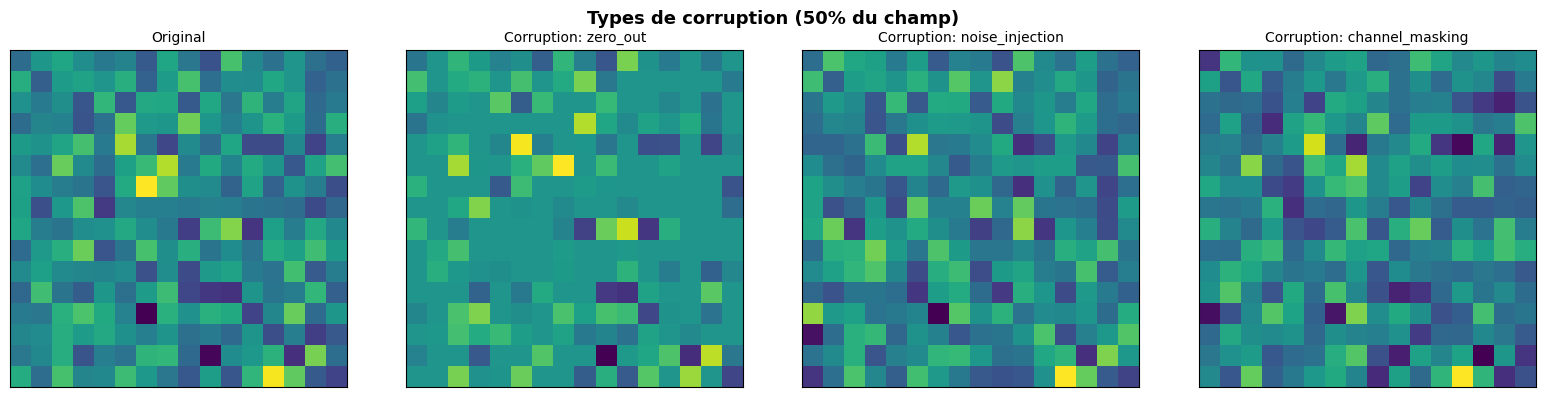

In [3]:
def corrupt_zero_out(state: torch.Tensor, ratio: float = 0.5) -> torch.Tensor:
    """
    Zero-out : mettre une fraction aleatoire des positions spatiales a zero.
    Simule une perte d'information brutale.
    """
    B, C, H, W = state.shape
    mask = torch.rand(B, 1, H, W, device=state.device) > ratio  # True = garder
    return state * mask.float()


def corrupt_noise_injection(state: torch.Tensor, ratio: float = 0.5,
                             noise_scale: float = 1.0) -> torch.Tensor:
    """
    Injection de bruit : remplacer une fraction par du bruit gaussien.
    Simule une corruption de l'information (pas juste une perte).
    """
    B, C, H, W = state.shape
    mask = torch.rand(B, 1, H, W, device=state.device) > ratio  # True = garder original
    noise = torch.randn_like(state) * noise_scale * state.std()
    return torch.where(mask.expand_as(state), state, noise)


def corrupt_channel_masking(state: torch.Tensor, ratio: float = 0.5) -> torch.Tensor:
    """
    Masquage de canaux : mettre des canaux entiers a zero.
    Simule la perte d'une modalite ou d'une composante de representation.
    """
    B, C, H, W = state.shape
    n_mask = int(C * ratio)
    indices = torch.randperm(C, device=state.device)[:n_mask]
    corrupted = state.clone()
    corrupted[:, indices, :, :] = 0.0
    return corrupted


CORRUPTION_TYPES = {
    'zero_out': corrupt_zero_out,
    'noise_injection': corrupt_noise_injection,
    'channel_masking': corrupt_channel_masking,
}

# Tester visuellement
torch.manual_seed(42)
test_state = torch.randn(1, CHANNELS, SPATIAL_HW, SPATIAL_HW, device=device)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, func) in zip(axes[1:], CORRUPTION_TYPES.items()):
    corrupted = func(test_state)
    ax.imshow(corrupted[0].mean(dim=0).cpu().numpy(), cmap='viridis')
    ax.set_title(f'Corruption: {name}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

axes[0].imshow(test_state[0].mean(dim=0).cpu().numpy(), cmap='viridis')
axes[0].set_title('Original', fontsize=10)
axes[0].set_xticks([]); axes[0].set_yticks([])

plt.suptitle('Types de corruption (50% du champ)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. SSIM for latent fields

In [4]:
def compute_ssim_field(field_a, field_b):
    """SSIM simplifie pour champs latents (B, C, H, W)."""
    C1, C2 = 0.01 ** 2, 0.03 ** 2
    a = field_a.mean(dim=1, keepdim=True)
    b = field_b.mean(dim=1, keepdim=True)
    mu_a = F.avg_pool2d(a, 3, 1, 1)
    mu_b = F.avg_pool2d(b, 3, 1, 1)
    sigma_a_sq = F.avg_pool2d(a**2, 3, 1, 1) - mu_a**2
    sigma_b_sq = F.avg_pool2d(b**2, 3, 1, 1) - mu_b**2
    sigma_ab = F.avg_pool2d(a*b, 3, 1, 1) - mu_a * mu_b
    ssim = ((2*mu_a*mu_b + C1) * (2*sigma_ab + C2)) / \
           ((mu_a**2 + mu_b**2 + C1) * (sigma_a_sq + sigma_b_sq + C2))
    return ssim.mean().item()

## 4. Resilience protocol

1. Evolve the BeliefField with a constant observation for N_WARMUP steps (reference)
2. Save the reference trajectory (no corruption)
3. At T=CORRUPT_STEP, corrupt the field
4. Continue evolving and measure divergence from the reference trajectory

In [5]:
@torch.no_grad()
def run_resilience_test(corruption_type: str, seed: int = 42):
    """
    Execute le test de resilience complet.
    
    Retourne les metriques de la trajectoire corrompue et de la reference.
    """
    torch.manual_seed(seed)
    
    # Creer le BeliefField
    bf = BeliefField(
        channels=CHANNELS, stimulus_dim=STIMULUS_DIM, spatial_hw=SPATIAL_HW,
        decay=0.95, n_evolve_steps=3, dilations=[1, 4],
        use_memory_pump=True, use_hebbian=True,
        use_deltanet=True, use_titans=True,
    ).to(device)
    bf.eval()
    
    # Observation constante (objet fixe)
    torch.manual_seed(seed + 100)
    obs = torch.randn(BATCH_SIZE, CHANNELS, SPATIAL_HW, SPATIAL_HW, device=device) * 0.3
    stimulus = torch.zeros(BATCH_SIZE, STIMULUS_DIM, device=device)
    
    total_steps = N_WARMUP + N_RECOVERY
    
    # --- Trajectoire de REFERENCE (sans corruption) ---
    torch.manual_seed(seed)
    bf_ref = BeliefField(
        channels=CHANNELS, stimulus_dim=STIMULUS_DIM, spatial_hw=SPATIAL_HW,
        decay=0.95, n_evolve_steps=3, dilations=[1, 4],
        use_memory_pump=True, use_hebbian=True,
        use_deltanet=True, use_titans=True,
    ).to(device)
    bf_ref.eval()
    # Copier les poids du modele principal
    bf_ref.load_state_dict(bf.state_dict())
    
    state_ref = bf_ref.init_state(BATCH_SIZE, device, torch.float32)
    ref_states = []
    
    for t in range(total_steps):
        state_ref = bf_ref.write(state_ref, obs)
        state_ref = bf_ref.evolve(state_ref, stimulus=stimulus)
        ref_states.append(state_ref.clone())
    
    # --- Trajectoire CORROMPUE ---
    state = bf.init_state(BATCH_SIZE, device, torch.float32)
    
    mse_to_ref = []
    ssim_to_ref = []
    energies = []
    snapshots = {}
    phase_labels = []
    
    corruption_fn = CORRUPTION_TYPES[corruption_type]
    
    for t in range(total_steps):
        # Ecriture de l'observation (le systeme recoit toujours l'input)
        state = bf.write(state, obs)
        
        # CORRUPTION au pas T
        if t == CORRUPT_STEP:
            snapshots['avant_corruption'] = state[0].cpu().clone()
            state = corruption_fn(state, ratio=CORRUPTION_RATIO)
            snapshots['apres_corruption'] = state[0].cpu().clone()
        
        state = bf.evolve(state, stimulus=stimulus)
        
        # Metriques vs reference
        ref_state_t = ref_states[t]
        mse = F.mse_loss(state, ref_state_t).item()
        ssim_val = compute_ssim_field(state, ref_state_t)
        energy = (state ** 2).sum(dim=(1, 2, 3)).mean().item()
        
        mse_to_ref.append(mse)
        ssim_to_ref.append(ssim_val)
        energies.append(energy)
        
        if t < CORRUPT_STEP:
            phase_labels.append('warmup')
        else:
            phase_labels.append('recovery')
        
        # Snapshots pendant la recovery
        if t == CORRUPT_STEP + 1:
            snapshots['recovery_1'] = state[0].cpu().clone()
        elif t == CORRUPT_STEP + 5:
            snapshots['recovery_5'] = state[0].cpu().clone()
        elif t == CORRUPT_STEP + 10:
            snapshots['recovery_10'] = state[0].cpu().clone()
        elif t == CORRUPT_STEP + 20:
            snapshots['recovery_20'] = state[0].cpu().clone()
    
    # Calculer le temps de recovery
    # = nombre de pas pour que la MSE redescende au niveau pre-corruption
    pre_corruption_mse = mse_to_ref[CORRUPT_STEP - 1] if CORRUPT_STEP > 0 else 0
    recovery_time = None
    for t in range(CORRUPT_STEP, total_steps):
        if mse_to_ref[t] <= pre_corruption_mse * 1.5:  # tolerance 50%
            recovery_time = t - CORRUPT_STEP
            break
    
    return {
        'mse_to_ref': mse_to_ref,
        'ssim_to_ref': ssim_to_ref,
        'energies': energies,
        'snapshots': snapshots,
        'recovery_time': recovery_time,
        'corruption_type': corruption_type,
        'phases': phase_labels,
    }

# Executer les tests
print("Test zero-out...")
res_zero = run_resilience_test('zero_out')
print("Test noise injection...")
res_noise = run_resilience_test('noise_injection')
print("Test channel masking...")
res_channel = run_resilience_test('channel_masking')
print("Termine!")

Test zero-out...
Test noise injection...
Test channel masking...
Termine!


## 5. Recovery curves: MSE and SSIM

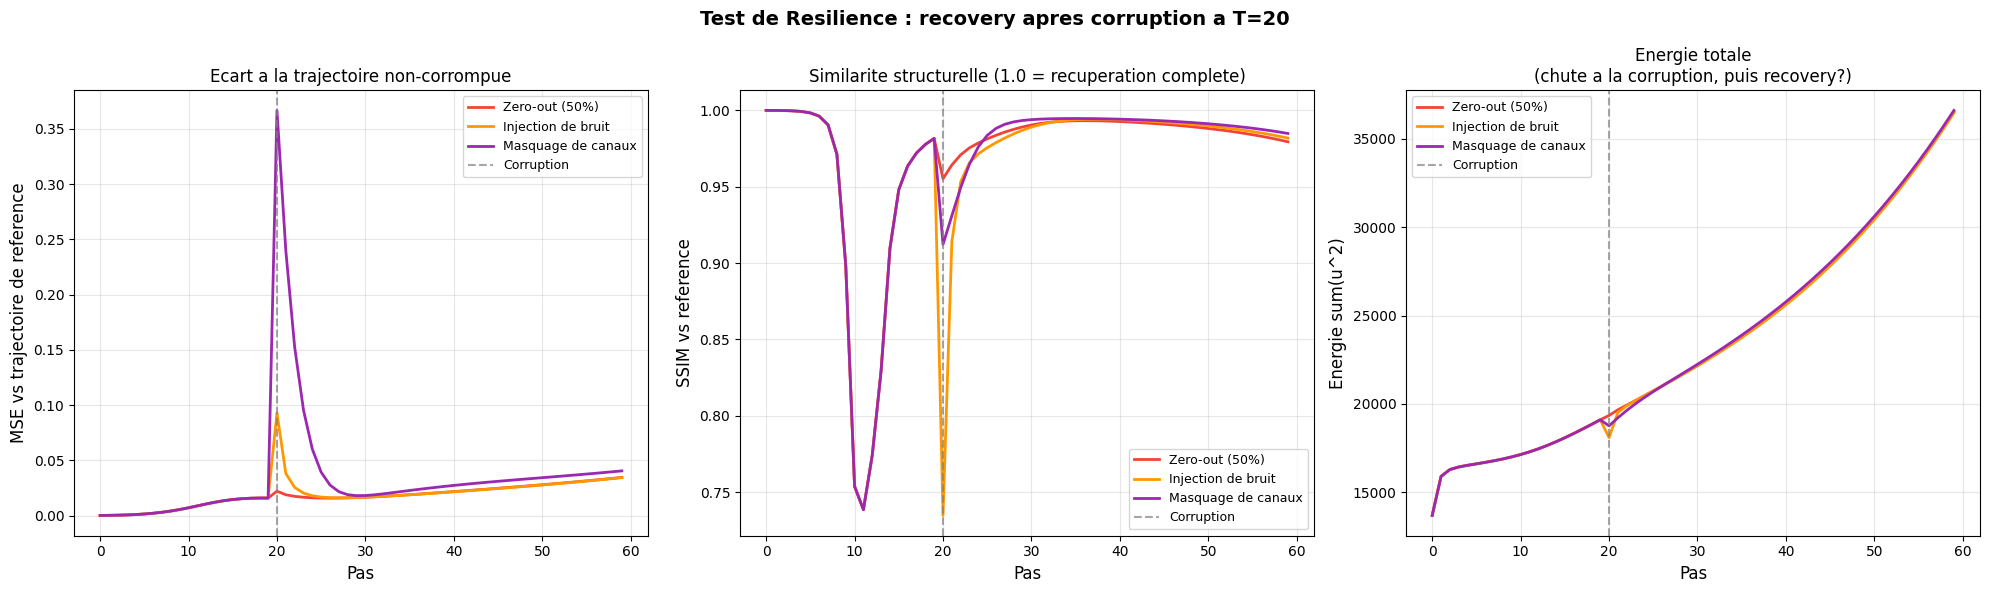

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = {'zero_out': '#F44336', 'noise_injection': '#FF9800', 'channel_masking': '#9C27B0'}
labels_fr = {'zero_out': 'Zero-out (50%)', 'noise_injection': 'Injection de bruit', 'channel_masking': 'Masquage de canaux'}

# MSE vs reference
ax = axes[0]
for res in [res_zero, res_noise, res_channel]:
    ct = res['corruption_type']
    ax.plot(res['mse_to_ref'], label=labels_fr[ct], color=colors[ct], linewidth=2)
ax.axvline(CORRUPT_STEP, color='gray', linestyle='--', alpha=0.7, label='Corruption')
ax.set_xlabel('Pas', fontsize=12)
ax.set_ylabel('MSE vs trajectoire de reference', fontsize=12)
ax.set_title('Ecart a la trajectoire non-corrompue', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# SSIM vs reference
ax = axes[1]
for res in [res_zero, res_noise, res_channel]:
    ct = res['corruption_type']
    ax.plot(res['ssim_to_ref'], label=labels_fr[ct], color=colors[ct], linewidth=2)
ax.axvline(CORRUPT_STEP, color='gray', linestyle='--', alpha=0.7, label='Corruption')
ax.set_xlabel('Pas', fontsize=12)
ax.set_ylabel('SSIM vs reference', fontsize=12)
ax.set_title('Similarite structurelle (1.0 = recuperation complete)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Energie
ax = axes[2]
for res in [res_zero, res_noise, res_channel]:
    ct = res['corruption_type']
    ax.plot(res['energies'], label=labels_fr[ct], color=colors[ct], linewidth=2)
ax.axvline(CORRUPT_STEP, color='gray', linestyle='--', alpha=0.7, label='Corruption')
ax.set_xlabel('Pas', fontsize=12)
ax.set_ylabel('Energie sum(u^2)', fontsize=12)
ax.set_title('Energie totale\n(chute a la corruption, puis recovery?)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Test de Resilience : recovery apres corruption a T=20', fontsize=14, fontweight='bold')
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_resilience_recovery.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_resilience_recovery.png'), bbox_inches='tight', dpi=150)
plt.show()

## 6. Recovery time

In [7]:
print("="*60)
print("TEMPS DE RECOVERY PAR TYPE DE CORRUPTION")
print("="*60)

for res in [res_zero, res_noise, res_channel]:
    ct = res['corruption_type']
    rt = res['recovery_time']
    
    # MSE au moment de la corruption vs fin
    mse_at_corrupt = res['mse_to_ref'][CORRUPT_STEP]
    mse_final = res['mse_to_ref'][-1]
    mse_pre = res['mse_to_ref'][CORRUPT_STEP - 1]
    
    print(f"\n  {labels_fr[ct]}:")
    print(f"    MSE pre-corruption:  {mse_pre:.6f}")
    print(f"    MSE post-corruption: {mse_at_corrupt:.6f} (x{mse_at_corrupt/max(mse_pre, 1e-10):.1f})")
    print(f"    MSE finale:          {mse_final:.6f}")
    
    if rt is not None:
        print(f"    Temps de recovery:   {rt} pas")
        print(f"    => AUTOPOIESE : le systeme se repare!")
    else:
        # Verifier si la MSE a au moins diminue
        mse_peak = max(res['mse_to_ref'][CORRUPT_STEP:])
        reduction = 1.0 - mse_final / max(mse_peak, 1e-10)
        print(f"    Temps de recovery:   Non atteint en {N_RECOVERY} pas")
        print(f"    Reduction MSE:       {reduction*100:.1f}% depuis le pic")
        if reduction > 0.5:
            print(f"    => RESILIENCE PARTIELLE : le systeme converge mais lentement")
        else:
            print(f"    => FRAGILE : le systeme ne se repare pas suffisamment")

TEMPS DE RECOVERY PAR TYPE DE CORRUPTION

  Zero-out (50%):
    MSE pre-corruption:  0.015898
    MSE post-corruption: 0.022143 (x1.4)
    MSE finale:          0.034578
    Temps de recovery:   0 pas
    => AUTOPOIESE : le systeme se repare!

  Injection de bruit:
    MSE pre-corruption:  0.015898
    MSE post-corruption: 0.092961 (x5.8)
    MSE finale:          0.034412
    Temps de recovery:   3 pas
    => AUTOPOIESE : le systeme se repare!

  Masquage de canaux:
    MSE pre-corruption:  0.015898
    MSE post-corruption: 0.366843 (x23.1)
    MSE finale:          0.040501
    Temps de recovery:   7 pas
    => AUTOPOIESE : le systeme se repare!


## 7. Field state during recovery

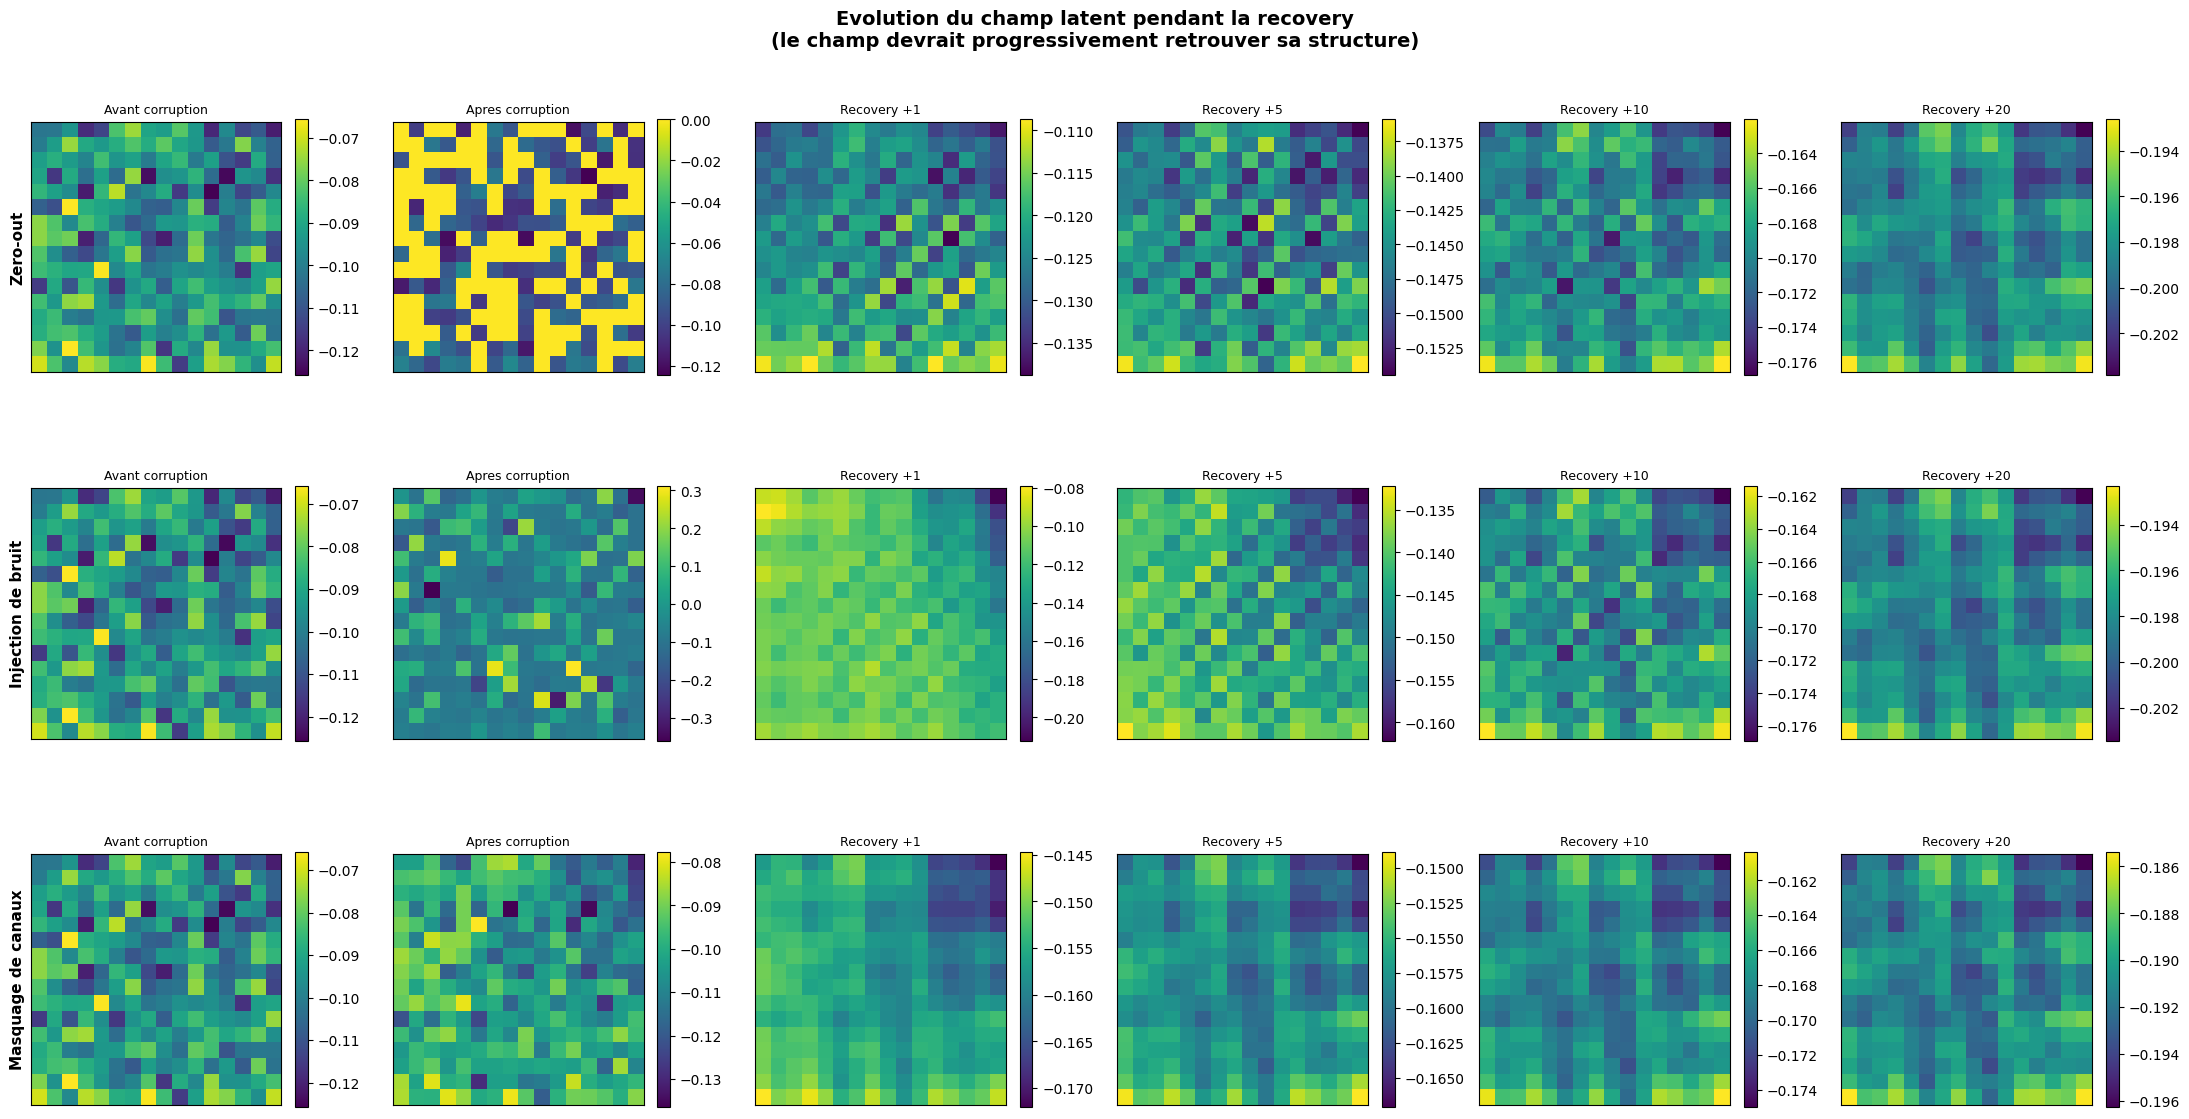

In [8]:
snapshot_keys = ['avant_corruption', 'apres_corruption', 'recovery_1', 'recovery_5', 'recovery_10', 'recovery_20']
snapshot_titles = ['Avant corruption', 'Apres corruption', 'Recovery +1', 'Recovery +5', 'Recovery +10', 'Recovery +20']

fig, axes = plt.subplots(3, len(snapshot_keys), figsize=(22, 12))

for row, (res, name) in enumerate([
    (res_zero, 'Zero-out'),
    (res_noise, 'Injection de bruit'),
    (res_channel, 'Masquage de canaux'),
]):
    for col, (key, title) in enumerate(zip(snapshot_keys, snapshot_titles)):
        ax = axes[row, col]
        if key in res['snapshots']:
            field = res['snapshots'][key].mean(dim=0).numpy()
            im = ax.imshow(field, cmap='viridis', aspect='equal')
            plt.colorbar(im, ax=ax, fraction=0.046)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title(title, fontsize=9)
        if col == 0:
            ax.set_ylabel(name, fontsize=11, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Evolution du champ latent pendant la recovery\n(le champ devrait progressivement retrouver sa structure)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Which corruption type is most damaging?

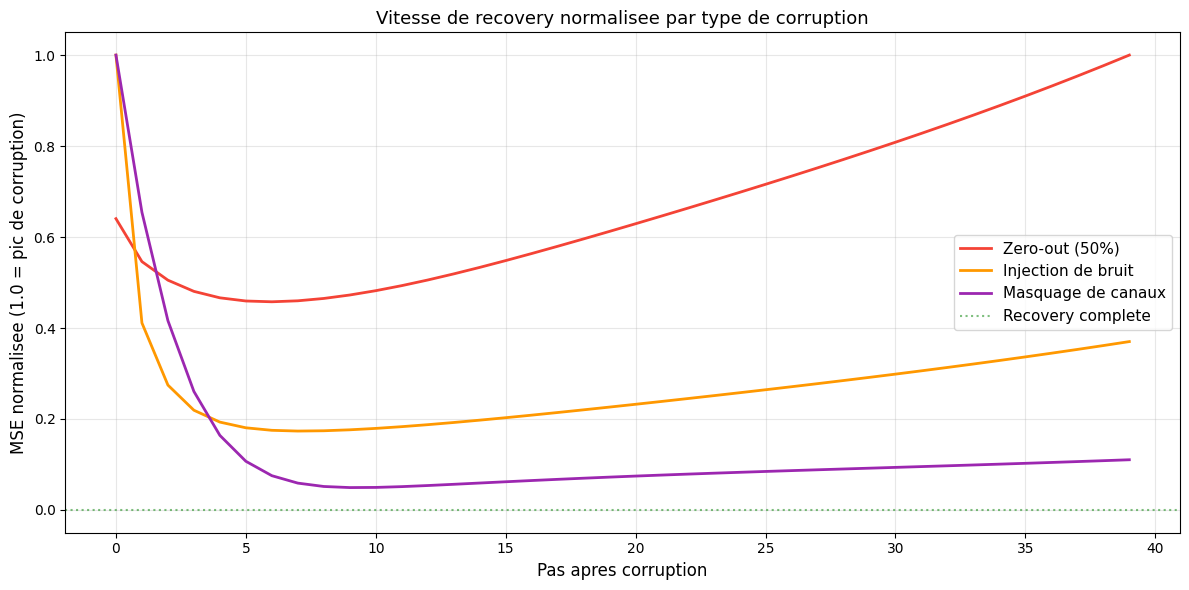

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

# Tracer uniquement la phase post-corruption, normalisee par la MSE au pic
for res in [res_zero, res_noise, res_channel]:
    ct = res['corruption_type']
    mse_post = res['mse_to_ref'][CORRUPT_STEP:]
    if len(mse_post) > 0 and max(mse_post) > 0:
        mse_normalized = [m / max(mse_post) for m in mse_post]
        ax.plot(mse_normalized, label=labels_fr[ct], color=colors[ct], linewidth=2)

ax.axhline(0.0, color='green', linestyle=':', alpha=0.5, label='Recovery complete')
ax.set_xlabel('Pas apres corruption', fontsize=12)
ax.set_ylabel('MSE normalisee (1.0 = pic de corruption)', fontsize=12)
ax.set_title('Vitesse de recovery normalisee par type de corruption', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Varying corruption ratios

  Ratio 10%... OK
  Ratio 25%... OK
  Ratio 50%... OK
  Ratio 75%... OK
  Ratio 90%... OK
Balayage des ratios termine!


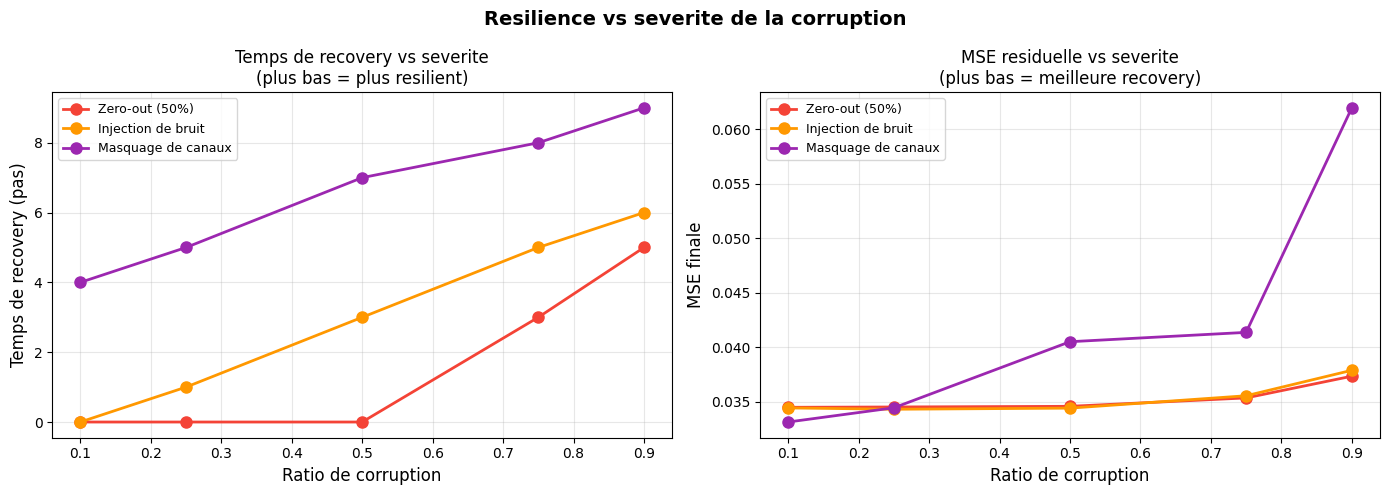

In [10]:
corruption_ratios = [0.1, 0.25, 0.5, 0.75, 0.9]
recovery_vs_ratio = {'zero_out': [], 'noise_injection': [], 'channel_masking': []}
final_mse_vs_ratio = {'zero_out': [], 'noise_injection': [], 'channel_masking': []}

# Sauvegarder le ratio global original
original_ratio = CORRUPTION_RATIO

for ratio in corruption_ratios:
    print(f"  Ratio {ratio:.0%}...", end=" ")
    # Modifier temporairement le ratio global utilise par run_resilience_test
    CORRUPTION_RATIO = ratio
    for ct_name in ['zero_out', 'noise_injection', 'channel_masking']:
        res = run_resilience_test(ct_name)
        recovery_vs_ratio[ct_name].append(res['recovery_time'])
        final_mse_vs_ratio[ct_name].append(res['mse_to_ref'][-1])
    print("OK")

# Restaurer le ratio original
CORRUPTION_RATIO = original_ratio

print("Balayage des ratios termine!")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ct_name, color in colors.items():
    # Recovery time (None -> N_RECOVERY pour le plot)
    rt = [t if t is not None else N_RECOVERY for t in recovery_vs_ratio[ct_name]]
    axes[0].plot(corruption_ratios, rt, marker='o', color=color, linewidth=2,
                label=labels_fr[ct_name], markersize=8)
    axes[1].plot(corruption_ratios, final_mse_vs_ratio[ct_name], marker='o', color=color,
                linewidth=2, label=labels_fr[ct_name], markersize=8)

axes[0].set_xlabel('Ratio de corruption', fontsize=12)
axes[0].set_ylabel('Temps de recovery (pas)', fontsize=12)
axes[0].set_title('Temps de recovery vs severite\n(plus bas = plus resilient)', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Ratio de corruption', fontsize=12)
axes[1].set_ylabel('MSE finale', fontsize=12)
axes[1].set_title('MSE residuelle vs severite\n(plus bas = meilleure recovery)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Resilience vs severite de la corruption', fontsize=14, fontweight='bold')
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_resilience_severity.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_resilience_severity.png'), bbox_inches='tight', dpi=150)
plt.show()

## Interpretation

### Autopoiesis

**Autopoiesis** (auto + poiesis = self-creation) comes from Maturana and Varela (1972). It describes systems that maintain and repair themselves. If FluidWorld shows this property:

1. The **PDE dynamics** have a basin of attraction wide enough to absorb perturbations
2. **Memory mechanisms** (Titans, Hebbian) preserve information even when the field gets disrupted
3. The **write mechanism** re-injects correct information from observations

### Possible outcomes

- **Full autopoiesis**: total recovery in a few steps. Excellent for robotics.
- **Partial resilience**: convergence without full recovery. Acceptable if residual MSE stays low.
- **Fragility**: divergence or no recovery. Needs an architectural fix (e.g. stronger write gate gain, adding a reset mechanism).

### Architectural implications

If zero-out is better tolerated than noise, that tells us missing information is less dangerous than corrupted information. Makes sense given how the surprise gate works in Titans.

### Next steps

- Test with a **trained** model (not just random weights)
- Measure resilience on real video sequences
- Compare against baselines (GRU state, Transformer KV cache)